In [3]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook')

# New structure: convergence/lambda:X,coils:Y/run_ZZ/results.json
CONV_DIR = '../examples/comparisons/closed_boundary_DIIID/convergence_w25'
BF_DIR   = '../examples/comparisons/closed_boundary_DIIID/brute_force'

rows = []
for config in sorted(os.listdir(CONV_DIR)):
    m = re.match(r'lambda:([^,]+),coils:(\d+)', config)
    if not m:
        continue
    lam, coils = float(m.group(1)), int(m.group(2))
    config_dir = os.path.join(CONV_DIR, config)

    # brute force baseline
    bf_path = os.path.join(BF_DIR, f'lambda:{lam},coils:{coils}', 'results.json')
    bf_cost = float('nan')
    if os.path.exists(bf_path):
        with open(bf_path) as f:
            bf_cost = json.load(f)['best_cost']

    for run_dir in sorted(os.listdir(config_dir)):
        rpath = os.path.join(config_dir, run_dir, 'results.json')
        if not os.path.isfile(rpath):
            continue
        run_m = re.match(r'run_(\d+)', run_dir)
        run_idx = int(run_m.group(1)) if run_m else 0

        with open(rpath) as f:
            data = json.load(f)

        lbfgs = data['methods'].get('Multi-start L-BFGS', {})
        bayes = data['methods'].get('Bayesian', {})
        if not bayes:
            continue

        ref_costs = bayes.get('refinement_costs', [])
        ref_evals = bayes.get('refinement_evals', [])
        ref_times = bayes.get('refinement_times', [])
        n_bo      = int(bayes.get('n_bayesian_evals', 0))
        n_initial = int(bayes.get('n_initial', 0))
        pts       = int(bayes.get('pts_refined', 0))

        rows.append({
            'config':            config,
            'lambda':            lam,
            'coils':             coils,
            'run':               run_idx,
            'random_state':      bayes.get('random_state'),
            # costs
            'bayes_cost':        bayes.get('best_cost', float('nan')),
            'lbfgs_cost':        lbfgs.get('best_cost', float('nan')),
            'bf_cost':           bf_cost,
            # eval counts
            'bayes_total_evals': int(bayes.get('n_evals', 0)),
            'n_initial':         n_initial,
            'n_gp_guided':       n_bo - n_initial,
            'n_gp_obs':          int(bayes.get('n_gp_observations', n_bo)),
            'lbfgs_evals':       int(lbfgs.get('n_evals', 0)),
            'lbfgs_starts':      int(lbfgs.get('starts_completed', 0)),
            # phase 2 acq params
            'acq_multiplier':    bayes.get('acq_multiplier'),
            'n_acq_candidates':  bayes.get('n_acq_candidates'),
            'acq_dedup_tol':     bayes.get('acq_dedup_tol'),
            'unique_target':     bayes.get('unique_refined_points'),
            'n_acq_unique':      bayes.get('n_acq_unique'),
            'pts_refined':       pts,
            # timing
            'bayes_time':        float(bayes.get('time', 0)),
            'bayes_phase1_time': float(bayes.get('time_bayesian_phase', 0)),
            'lbfgs_time':        float(lbfgs.get('time', 0)),
            'total_ref_time':    sum(ref_times) if ref_times else float('nan'),
            # stopping
            'bayes_stopping':    bayes.get('bayesian_stopping'),
            'ref_stopping':      bayes.get('refinement_stopping'),
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} runs across {df["config"].nunique()} configs')
df.head()

Loaded 360 runs across 16 configs


,config,lambda,coils,run,random_state,bayes_cost,lbfgs_cost,bf_cost,bayes_total_evals,n_initial,...,acq_dedup_tol,unique_target,n_acq_unique,pts_refined,bayes_time,bayes_phase1_time,lbfgs_time,total_ref_time,bayes_stopping,ref_stopping
0,"lambda:1e-05,coils:2",0.00001,2,1,2,0.032574,0.032574,0.033003,837,71,...,0.05,5,5,5,244.015587,97.602289,6.878936,1.506958,bayesian_stagnation,all refinements completed
1,"lambda:1e-05,coils:2",0.00001,2,2,3,0.032574,0.032574,0.033003,975,71,...,0.05,5,5,5,235.166422,87.388173,6.323568,1.699480,bayesian_stagnation,all refinements completed
2,"lambda:1e-05,coils:2",0.00001,2,3,4,0.032574,0.032574,0.033003,572,71,...,0.05,5,5,5,248.989643,93.941564,7.895107,1.042871,bayesian_stagnation,all refinements completed
3,"lambda:1e-05,coils:2",0.00001,2,4,5,0.032574,0.032574,0.033003,665,71,...,0.05,5,5,5,180.906725,64.661674,7.260349,1.154453,bayesian_stagnation,all refinements completed
4,"lambda:1e-05,coils:2",0.00001,2,5,6,0.032574,0.032574,0.033003,698,71,...,0.05,5,5,5,219.049093,81.129230,6.789239,1.191525,bayesian_stagnation,all refinements completed


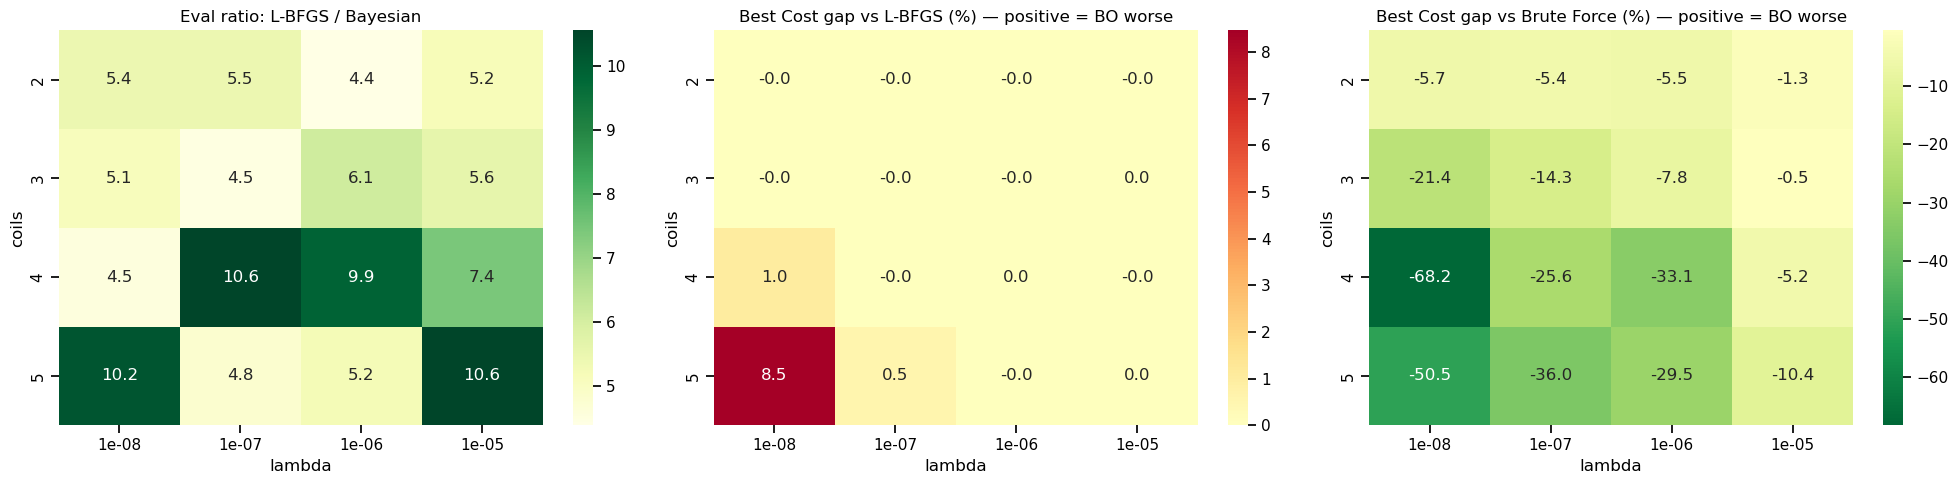

In [4]:
# Best cost per config (best run if multiple)
best = df.sort_values('bayes_cost').groupby('config', sort=False).first().reset_index()
best['cost_gap_lbfgs'] = (best['bayes_cost'] - best['lbfgs_cost']) / best['lbfgs_cost'] * 100
best['cost_gap_bf']    = (best['bayes_cost'] - best['bf_cost'])    / best['bf_cost']    * 100
best['eval_ratio']     = best['lbfgs_evals'] / best['bayes_total_evals']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title, fmt in [
    (axes[0], 'eval_ratio',     'Eval ratio: L-BFGS / Bayesian',                   '.1f'),
    (axes[1], 'cost_gap_lbfgs', 'Best Cost gap vs L-BFGS (%) — positive = BO worse',    '.1f'),
    (axes[2], 'cost_gap_bf',    'Best Cost gap vs Brute Force (%) — positive = BO worse','.1f'),
]:
    pivot = best.pivot_table(index='coils', columns='lambda', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    cmap  = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

In [9]:
# Runs analyzed per (coils, lambda)
counts = df.groupby(['coils', 'lambda']).size().reset_index(name='n_runs')
pivot = counts.pivot(index='coils', columns='lambda', values='n_runs').fillna(0).astype(int)
pivot.columns = [f'{c:.0e}' for c in pivot.columns]
display(pivot)

,1e-08,1e-07,1e-06,1e-05
coils,,,,
2,20,20,20,20
3,20,20,20,20
4,20,20,20,20
5,20,40,40,20


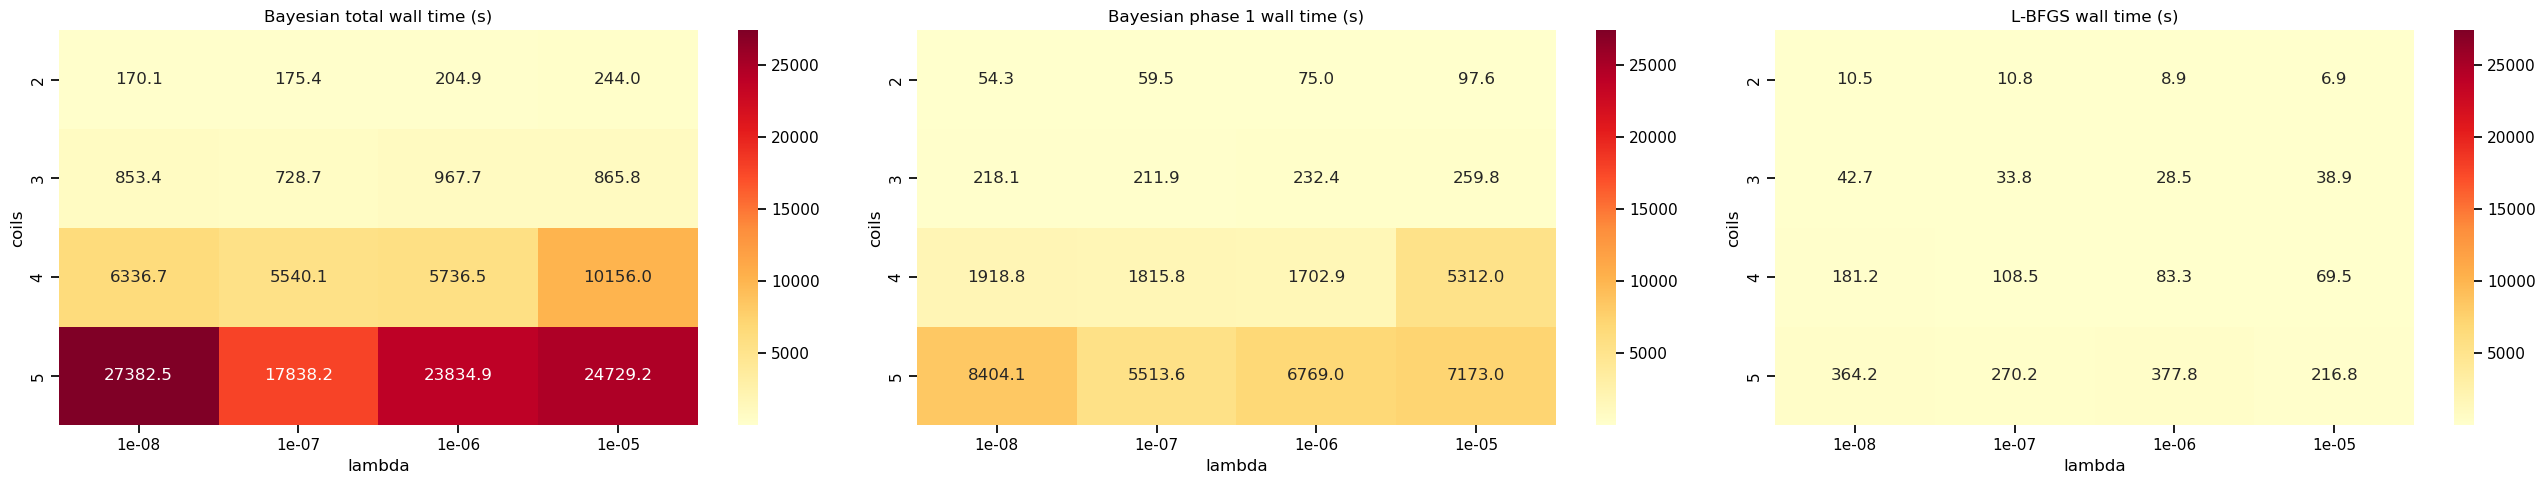

In [10]:
# Wall-clock time breakdown
timing = df.groupby(['coils', 'lambda']).first().reset_index()

lams = sorted(timing['lambda'].unique())
pivots = {
    col: timing.pivot_table(index='coils', columns='lambda', values=col).reindex(lams, axis=1)
    for col in ['bayes_time', 'bayes_phase1_time', 'lbfgs_time']
}

vmin = min(p.min().min() for p in pivots.values())
vmax = max(p.max().max() for p in pivots.values())

titles = {
    'bayes_time':       'Bayesian total wall time (s)',
    'bayes_phase1_time':'Bayesian phase 1 wall time (s)',
    'lbfgs_time':       'L-BFGS wall time (s)',
}

fig, axes = plt.subplots(1, 3, figsize=(26, 5))
for ax, (col, pivot) in zip(axes, pivots.items()):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
    ax.set_title(titles[col])
    ax.set_xlabel('lambda')
    ax.set_ylabel('coils')

plt.tight_layout()
plt.show()

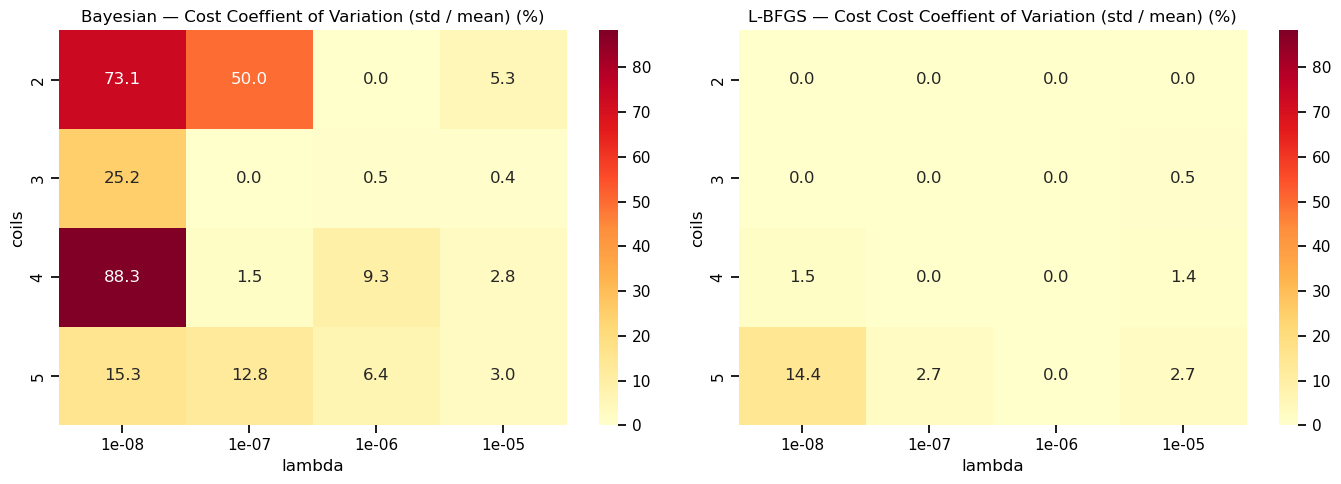

,coils,lambda,n,bayes_mean,bayes_std,bayes_cv,lbfgs_mean,lbfgs_std,lbfgs_cv
0,2,1.000000e-08,20,0.004328,3.163950e-03,7.310479e+01,0.002862,4.168011e-13,1.456287e-08
1,2,1.000000e-07,20,0.004061,2.030678e-03,5.000331e+01,0.002925,1.787085e-13,6.108854e-09
2,2,1.000000e-06,20,0.005956,6.126442e-12,1.028695e-07,0.005956,4.605797e-14,7.733626e-10
3,2,1.000000e-05,20,0.033388,1.772289e-03,5.308136e+00,0.032574,1.451054e-15,4.454685e-12
4,3,1.000000e-08,20,0.000047,1.184252e-05,2.517433e+01,0.000044,2.946517e-11,6.637936e-05
5,3,1.000000e-07,20,0.000091,2.682789e-11,2.946802e-05,0.000091,5.442710e-12,5.978327e-06
6,3,1.000000e-06,20,0.002788,1.501036e-05,5.383711e-01,0.002785,2.016246e-12,7.240312e-08
7,3,1.000000e-05,20,0.030717,1.255398e-04,4.086929e-01,0.030592,1.401075e-04,4.579815e-01
8,4,1.000000e-08,20,0.000014,1.278071e-05,8.829505e+01,0.000008,1.194569e-07,1.458147e+00
9,4,1.000000e-07,20,0.000054,7.938026e-07,1.465319e+00,0.000053,1.166679e-08,2.186097e-02


In [11]:
# Cost CV across runs (std / mean * 100%) per method — higher = more variable across seeds
multi = df.groupby(['coils', 'lambda']).filter(lambda g: len(g) > 1)

if len(multi) == 0:
    print('Only single runs found — re-run with N_RUNS > 1 to see variance.')
else:
    stats = multi.groupby(['coils', 'lambda']).agg(
        bayes_mean=('bayes_cost', 'mean'), bayes_std=('bayes_cost', 'std'),
        lbfgs_mean=('lbfgs_cost', 'mean'), lbfgs_std=('lbfgs_cost', 'std'),
        n=('bayes_cost', 'count'),
    ).reset_index()
    stats['bayes_cv'] = stats['bayes_std'] / stats['bayes_mean'] * 100
    stats['lbfgs_cv'] = stats['lbfgs_std'] / stats['lbfgs_mean'] * 100

    vmin = min(stats['bayes_cv'].min(), stats['lbfgs_cv'].min())
    vmax = max(stats['bayes_cv'].max(), stats['lbfgs_cv'].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in [
        (axes[0], 'bayes_cv', 'Bayesian — Cost Coeffient of Variation (std / mean) (%)'),
        (axes[1], 'lbfgs_cv', 'L-BFGS — Cost Cost Coeffient of Variation (std / mean) (%)'),
    ]:
        pivot = stats.pivot_table(index='coils', columns='lambda', values=col)
        pivot = pivot.reindex(sorted(pivot.columns), axis=1)
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel('lambda')
        ax.set_ylabel('coils')

    plt.tight_layout()
    plt.show()
    display(stats[['coils', 'lambda', 'n', 'bayes_mean', 'bayes_std', 'bayes_cv', 'lbfgs_mean', 'lbfgs_std', 'lbfgs_cv']])